In [13]:
# =========================================================
# STEP 1: Data Loading, Encoding, and Splitting (1-Day)
# =========================================================
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

data_path = '../../data/tomato_with_temp_1day.csv'
print("Loading 1-day model ready data...")
df = pd.read_csv(data_path)
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

# 1. Encode Categoricals for LightGBM
categorical_cols = ['mandi_name', 'district', 'state', 'variety']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 2. Chronological Train/Test Split
split_date = '2025-03-01'
train_df = df[df['arrival_date'] < split_date].copy()
test_df = df[df['arrival_date'] >= split_date].copy()

# 3. Drop Leaky Columns
drop_cols = [
    'arrival_date', 'target_price', 'commodity',
    'modal_price', 'min_price', 'max_price'
]

X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['target_price']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['target_price']

print("\n--- CHECKPOINT 1 COMPLETE ---")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")
print(f"Features used: {list(X_train.columns)}")

Loading 1-day model ready data...

--- CHECKPOINT 1 COMPLETE ---
Training features shape: (13622, 27)
Testing features shape:  (3100, 27)
Features used: ['mandi_name', 'district', 'state', 'variety', 'is_real_trade', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_7', 'price_roll_mean_7', 'price_roll_std_7', 'price_roll_mean_30', 'price_expanding_mean', 'sin_365_1', 'cos_365_1', 'sin_365_2', 'cos_365_2', 'temp_mean_lag1', 'rainfall_lag1', 'rainfall_7d_sum', 'rainfall_30d_sum', 'temp_7d_avg']


In [14]:
# =========================================================
# STEP 2: LightGBM Datasets & Quantile Training (1-Day)
# =========================================================
import lightgbm as lgb
import os

print("Creating LightGBM datasets...")

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols, free_raw_data=False)
lgb_eval = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_cols, reference=lgb_train, free_raw_data=False)

base_params = {
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

quantile_configs = {
    'p50': {
        'alpha': 0.50, 'max_depth': 9, 'num_leaves': 63,
        'min_data_in_leaf': 20, 'lambda_l1': 0.1, 'lambda_l2': 0.1
    },
    'p10': {
        'alpha': 0.10, 'max_depth': 5, 'num_leaves': 31,
        'min_data_in_leaf': 20, 'lambda_l1': 0.1, 'lambda_l2': 0.1
    },
    'p90': {
        'alpha': 0.90, 'max_depth': 5, 'num_leaves': 31,
        'min_data_in_leaf': 20, 'lambda_l1': 0.1, 'lambda_l2': 0.1
    }
}

models = {}
print("\nStarting 1-Day Horizon Probabilistic Training...")

for name, config in quantile_configs.items():
    print(f"\n--- Training {name} Model (Alpha={config['alpha']}) ---")
    params = {**base_params, **config}
    params['objective'] = 'quantile'
    params['metric'] = 'quantile'

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, first_metric_only=False),
        lgb.log_evaluation(period=200)
    ]

    model = lgb.train(
        params, lgb_train, num_boost_round=2000,
        valid_sets=[lgb_train, lgb_eval],
        valid_names=['train', 'eval'],
        callbacks=callbacks
    )
    models[name] = model

    model_path = f"../../data/tomato_lgbm_{name}_1day.txt"
    model.save_model(model_path)
    print(f"Saved: {model_path}")

print("\n--- CHECKPOINT 2 COMPLETE: All 1-Day Models Trained & Saved ---")

Creating LightGBM datasets...

Starting 1-Day Horizon Probabilistic Training...

--- Training p50 Model (Alpha=0.5) ---
Training until validation scores don't improve for 50 rounds
[200]	train's quantile: 90.7746	eval's quantile: 141.084
Early stopping, best iteration is:
[271]	train's quantile: 86.5712	eval's quantile: 139.769
Saved: ../../data/tomato_lgbm_p50_1day.txt

--- Training p10 Model (Alpha=0.1) ---
Training until validation scores don't improve for 50 rounds
[200]	train's quantile: 49.5602	eval's quantile: 64.7338
Early stopping, best iteration is:
[230]	train's quantile: 48.161	eval's quantile: 64.5536
Saved: ../../data/tomato_lgbm_p10_1day.txt

--- Training p90 Model (Alpha=0.9) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[131]	train's quantile: 56.0421	eval's quantile: 79.0111
Saved: ../../data/tomato_lgbm_p90_1day.txt

--- CHECKPOINT 2 COMPLETE: All 1-Day Models Trained & Saved ---


In [15]:
# =========================================================
# STEP 3: Generate Formal Performance Metrics (1-Day)
# =========================================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

print("Generating 1-Day predictions on unseen test data...\n")

results_df = test_df[['arrival_date', 'mandi_name', 'target_price']].copy()

for name in ['p10', 'p50', 'p90']:
    results_df[f'{name}_pred'] = models[name].predict(X_test)

mae = mean_absolute_error(results_df['target_price'], results_df['p50_pred'])
rmse = np.sqrt(mean_squared_error(results_df['target_price'], results_df['p50_pred']))
mape = mean_absolute_percentage_error(results_df['target_price'], results_df['p50_pred'])

results_df['in_bound'] = (results_df['target_price'] >= results_df['p10_pred']) & (results_df['target_price'] <= results_df['p90_pred'])
coverage = results_df['in_bound'].mean() * 100

print("=" * 50)
print("FINAL 1-DAY HORIZON METRICS")
print("=" * 50)
print(f"MAE:  \u20b9 {mae:.2f}")
print(f"RMSE: \u20b9 {rmse:.2f}")
print(f"MAPE: {mape*100:.2f}%")
print(f"80% Prediction Interval Coverage: {coverage:.1f}%")
print("=" * 50)

Generating 1-Day predictions on unseen test data...

FINAL 1-DAY HORIZON METRICS
MAE:  ₹ 279.54
RMSE: ₹ 433.33
MAPE: 21.58%
80% Prediction Interval Coverage: 77.9%


In [16]:
# REAL TRADE DAYS ONLY METRICS
real_mask = X_test['is_real_trade'] == 1
y_real = y_test[real_mask]
pred_real = results_df['p50_pred'][real_mask]

mae_real = mean_absolute_error(y_real, pred_real)
rmse_real = np.sqrt(mean_squared_error(y_real, pred_real))
mape_real = np.mean(np.abs((y_real - pred_real) / y_real)) * 100

print("=" * 50)
print("REAL TRADE DAYS ONLY METRICS")
print("=" * 50)
print(f"MAE:  ₹ {mae_real:.2f}")
print(f"RMSE: ₹ {rmse_real:.2f}")
print(f"MAPE: {mape_real:.2f}%")
print("=" * 50)


REAL TRADE DAYS ONLY METRICS
MAE:  ₹ 302.65
RMSE: ₹ 454.56
MAPE: 18.07%


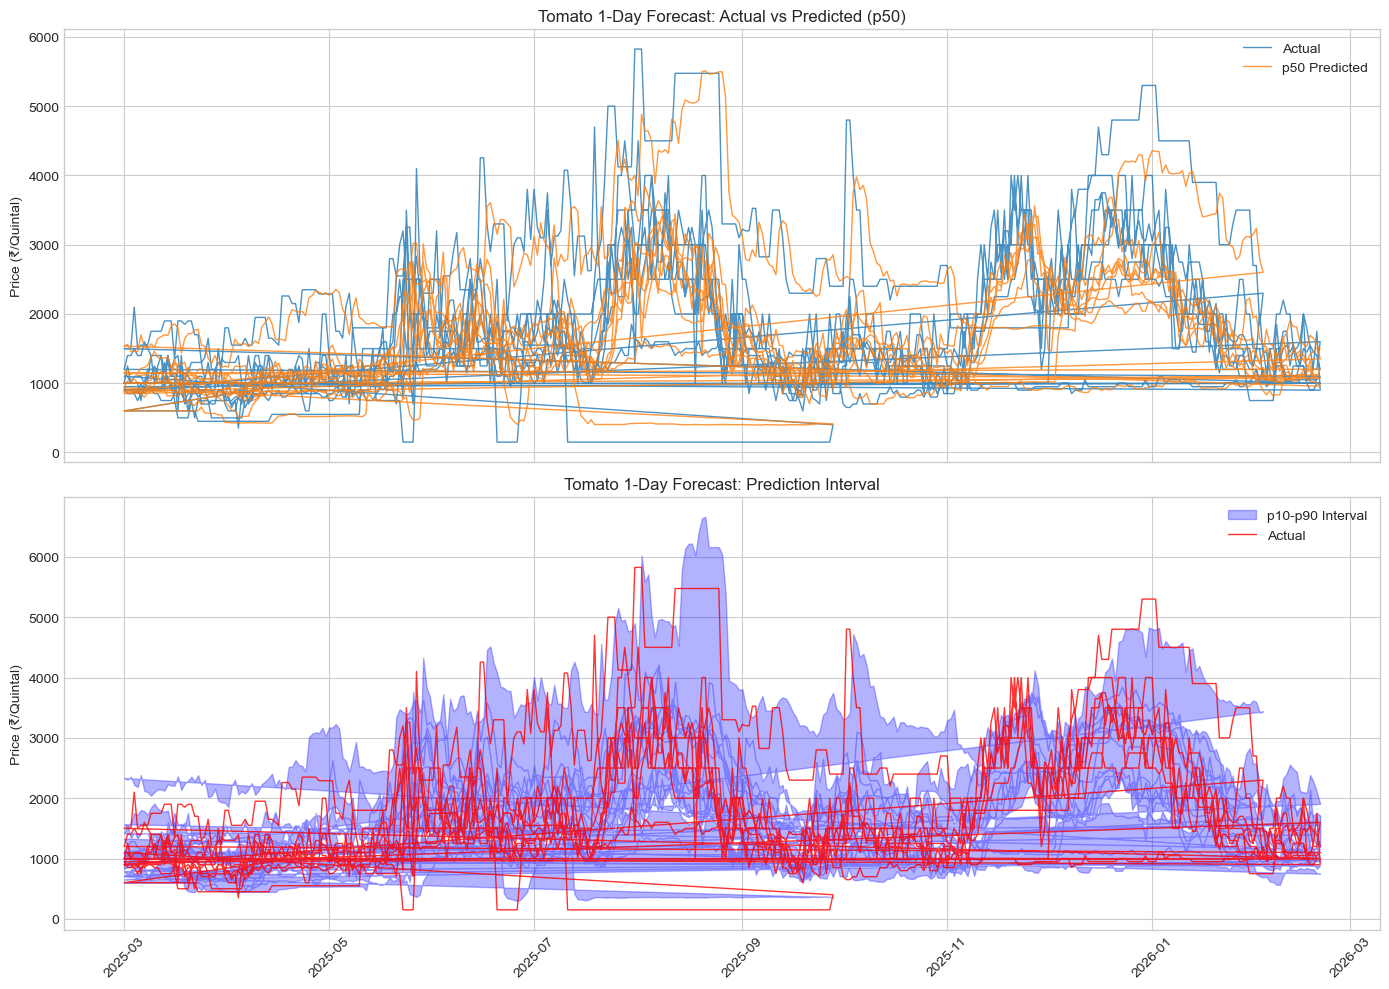

In [17]:
# =========================================================
# STEP 4: Visualization
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Actual vs p50 Predicted
ax1 = axes[0]
ax1.plot(results_df['arrival_date'], results_df['target_price'], label='Actual', linewidth=1, alpha=0.8)
ax1.plot(results_df['arrival_date'], results_df['p50_pred'], label='p50 Predicted', linewidth=1, alpha=0.8)
ax1.set_title('Tomato 1-Day Forecast: Actual vs Predicted (p50)')
ax1.set_ylabel('Price (\u20b9/Quintal)')
ax1.legend()

# Plot 2: Prediction Interval Ribbon
ax2 = axes[1]
ax2.fill_between(results_df['arrival_date'], results_df['p10_pred'], results_df['p90_pred'],
                  alpha=0.3, label='p10-p90 Interval', color='blue')
ax2.plot(results_df['arrival_date'], results_df['target_price'], label='Actual', linewidth=1, color='red', alpha=0.8)
ax2.set_title('Tomato 1-Day Forecast: Prediction Interval')
ax2.set_ylabel('Price (\u20b9/Quintal)')
ax2.legend()

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()